# Laboratorio 4 - VuelaAlpes

## Integrantes

- Isabella Naranjo
- David Caro

## 1. Exploración de los datos

### Carga de datos

Verificamos que los datos se cargaron correctamente y analizamos su estructura.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Datos_VuelaAlpes.csv')
print("Verificamos que los datos cargaron correctamente: ")
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 100)

print(df.head())
print('\n')
print(df.tail())
print('\nDimensiones del DataFrame: ')
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Total de celdas: {df.size}")

Verificamos que los datos cargaron correctamente: 
       id  Gender   Customer Type  Age   Type of Travel     Class  \
0  119496    Male  Loyal Customer   29  Business travel  Business   
1   60419    Male  Loyal Customer   54  Business travel  Business   
2    9671    Male  Loyal Customer   52  Business travel       Eco   
3   59115  Female  Loyal Customer   17  Personal Travel       Eco   
4   75857  Female  Loyal Customer   30  Personal Travel       Eco   

   Flight Distance  Inflight wifi service  Departure/Arrival time convenient  \
0              814                      3                                  3   
1             2913                      4                                  4   
2              277                      4                                  5   
3             1744                      3                                  0   
4             1440                      3                                  4   

   Ease of Online booking  Gate location  Food and dr

### Perfilamiento general del conjunto de datos

Realizamos un perfilamiento inicial para entender el tamaño del dataset, la distribución general de tipos de variables y el nivel global de completitud.

In [2]:
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = df.select_dtypes(include=['object', 'str']).columns.tolist()

resumen_general = pd.DataFrame({
    'Métrica': [
        'Número de filas',
        'Número de columnas',
        'Variables numéricas',
        'Variables categóricas',
        'Total de valores nulos',
        'Porcentaje global de valores nulos'
    ],
    'Valor': [
        df.shape[0],
        df.shape[1],
        len(variables_numericas),
        len(variables_categoricas),
        df.isnull().sum().sum(),
        f'{(round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 4)) * 100} %'
    ]
})

display(resumen_general)

,Métrica,Valor
0,Número de filas,10000
1,Número de columnas,23
2,Variables numéricas,19
3,Variables categóricas,4
4,Total de valores nulos,25
5,Porcentaje global de valores nulos,1.09 %


Verificamos que el tipo de variable del diccionario coincida con el tipo de variable de los datos en el dataset, y realizamos un primer acercamiento respecto a los valores nulos presentes en cada variable.

In [19]:
df.info()

revision_tipos = pd.DataFrame({
    'Variable': df.columns,
    'Tipo actual': df.dtypes.astype(str).values
})

revision_tipos['Observación'] = ''

observaciones = {
    'id': 'Identificador único, no aporta información predictiva — excluir del modelado',
    'Inflight wifi service': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Departure/Arrival time convenient': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Ease of Online booking': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Gate location': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Food and drink': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Online boarding': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Seat comfort': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Inflight entertainment': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'On-board service': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Leg room service': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Baggage handling': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Checkin service': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Inflight service': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Cleanliness': 'Numérica entera, pero semánticamente ordinal (escala 0-5)',
    'Arrival Delay in Minutes': 'Float con 25 nulos — única variable con valores faltantes'
}

for var, obs in observaciones.items():
    if var in revision_tipos['Variable'].values:
        revision_tipos.loc[revision_tipos['Variable'] == var, 'Observación'] = obs

pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)
display(revision_tipos)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 10000 non-null  int64  
 1   Gender                             10000 non-null  str    
 2   Customer Type                      10000 non-null  str    
 3   Age                                10000 non-null  int64  
 4   Type of Travel                     10000 non-null  str    
 5   Class                              10000 non-null  str    
 6   Flight Distance                    10000 non-null  int64  
 7   Inflight wifi service              10000 non-null  int64  
 8   Departure/Arrival time convenient  10000 non-null  int64  
 9   Ease of Online booking             10000 non-null  int64  
 10  Gate location                      10000 non-null  int64  
 11  Food and drink                     10000 non-null  int64  
 12  On

,Variable,Tipo actual,Observación
0,id,int64,"Identificador único, no aporta información pre..."
1,Gender,str,
2,Customer Type,str,
3,Age,int64,
4,Type of Travel,str,
5,Class,str,
6,Flight Distance,int64,
7,Inflight wifi service,int64,"Numérica entera, pero semánticamente ordinal (..."
8,Departure/Arrival time convenient,int64,"Numérica entera, pero semánticamente ordinal (..."
9,Ease of Online booking,int64,"Numérica entera, pero semánticamente ordinal (..."


Realizamos un primer acercamiento a la exploración de outliers y valores imposibles en las variables númericas.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,10000.0,64983.058500,37610.205164,1.0,32452.0,64815.5,97470.0,129879.0
Age,10000.0,39.404300,15.072364,7.0,27.0,40.0,51.0,80.0
Flight Distance,10000.0,1196.044800,1000.590808,31.0,416.0,846.0,1744.0,4963.0
Inflight wifi service,10000.0,2.734700,1.328718,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,10000.0,3.074000,1.520511,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,10000.0,2.762600,1.394287,0.0,2.0,3.0,4.0,5.0
Gate location,10000.0,3.002800,1.283182,1.0,2.0,3.0,4.0,5.0
Food and drink,10000.0,3.215200,1.324486,0.0,2.0,3.0,4.0,5.0
Online boarding,10000.0,3.234500,1.350293,0.0,2.0,3.0,4.0,5.0
Seat comfort,10000.0,3.431300,1.314935,1.0,2.0,4.0,4.0,5.0


### Exploración univariada de variables numéricas

Analizamos la distribución y posibles valores atípicos de las variables numéricas continuas mediante histogramas y diagramas de caja.

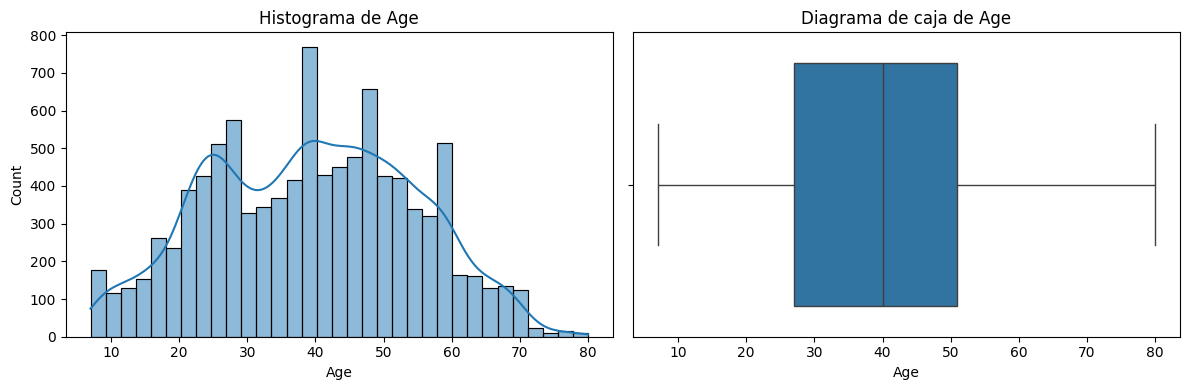

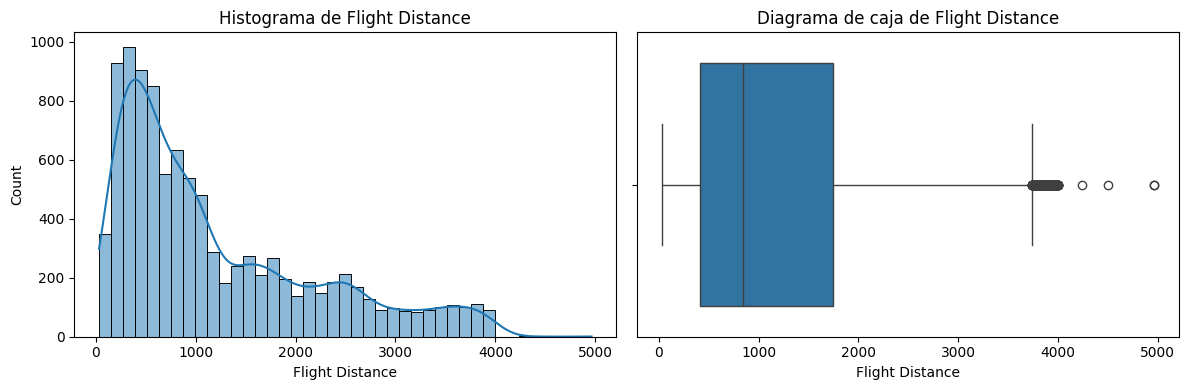

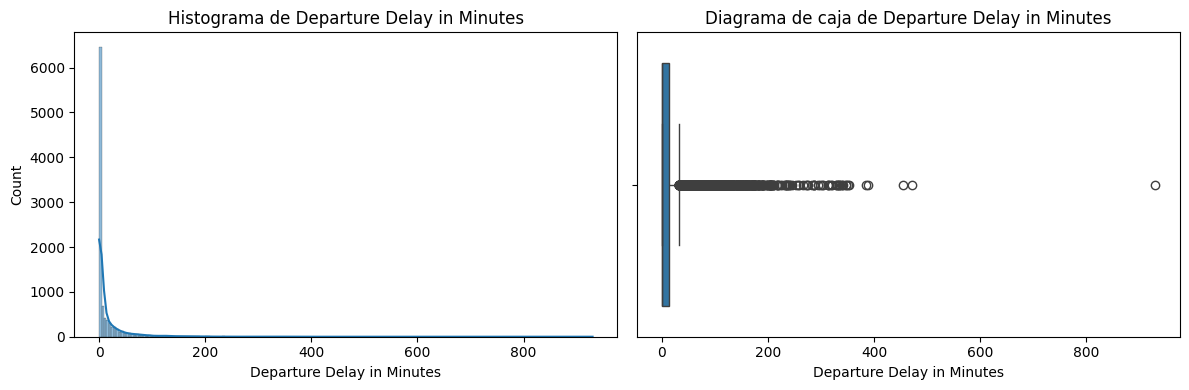

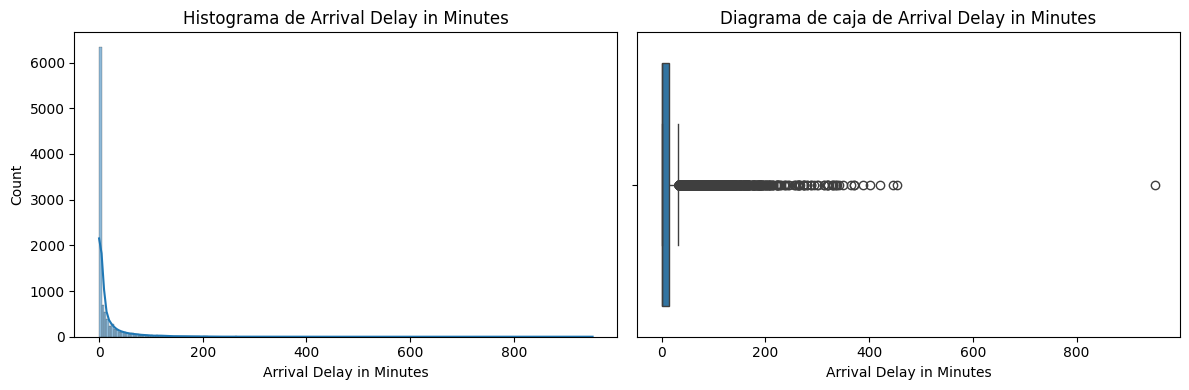

In [5]:
cols_numericas_clave = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

for col in cols_numericas_clave:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')
    
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Diagrama de caja de {col}')
    
    plt.tight_layout()
    plt.show()

Exploramos las variables de calificación (escala 0–5) de forma conjunta, ya que su distribución es ordinal y tiene un comportamiento diferente al de las variables continuas.

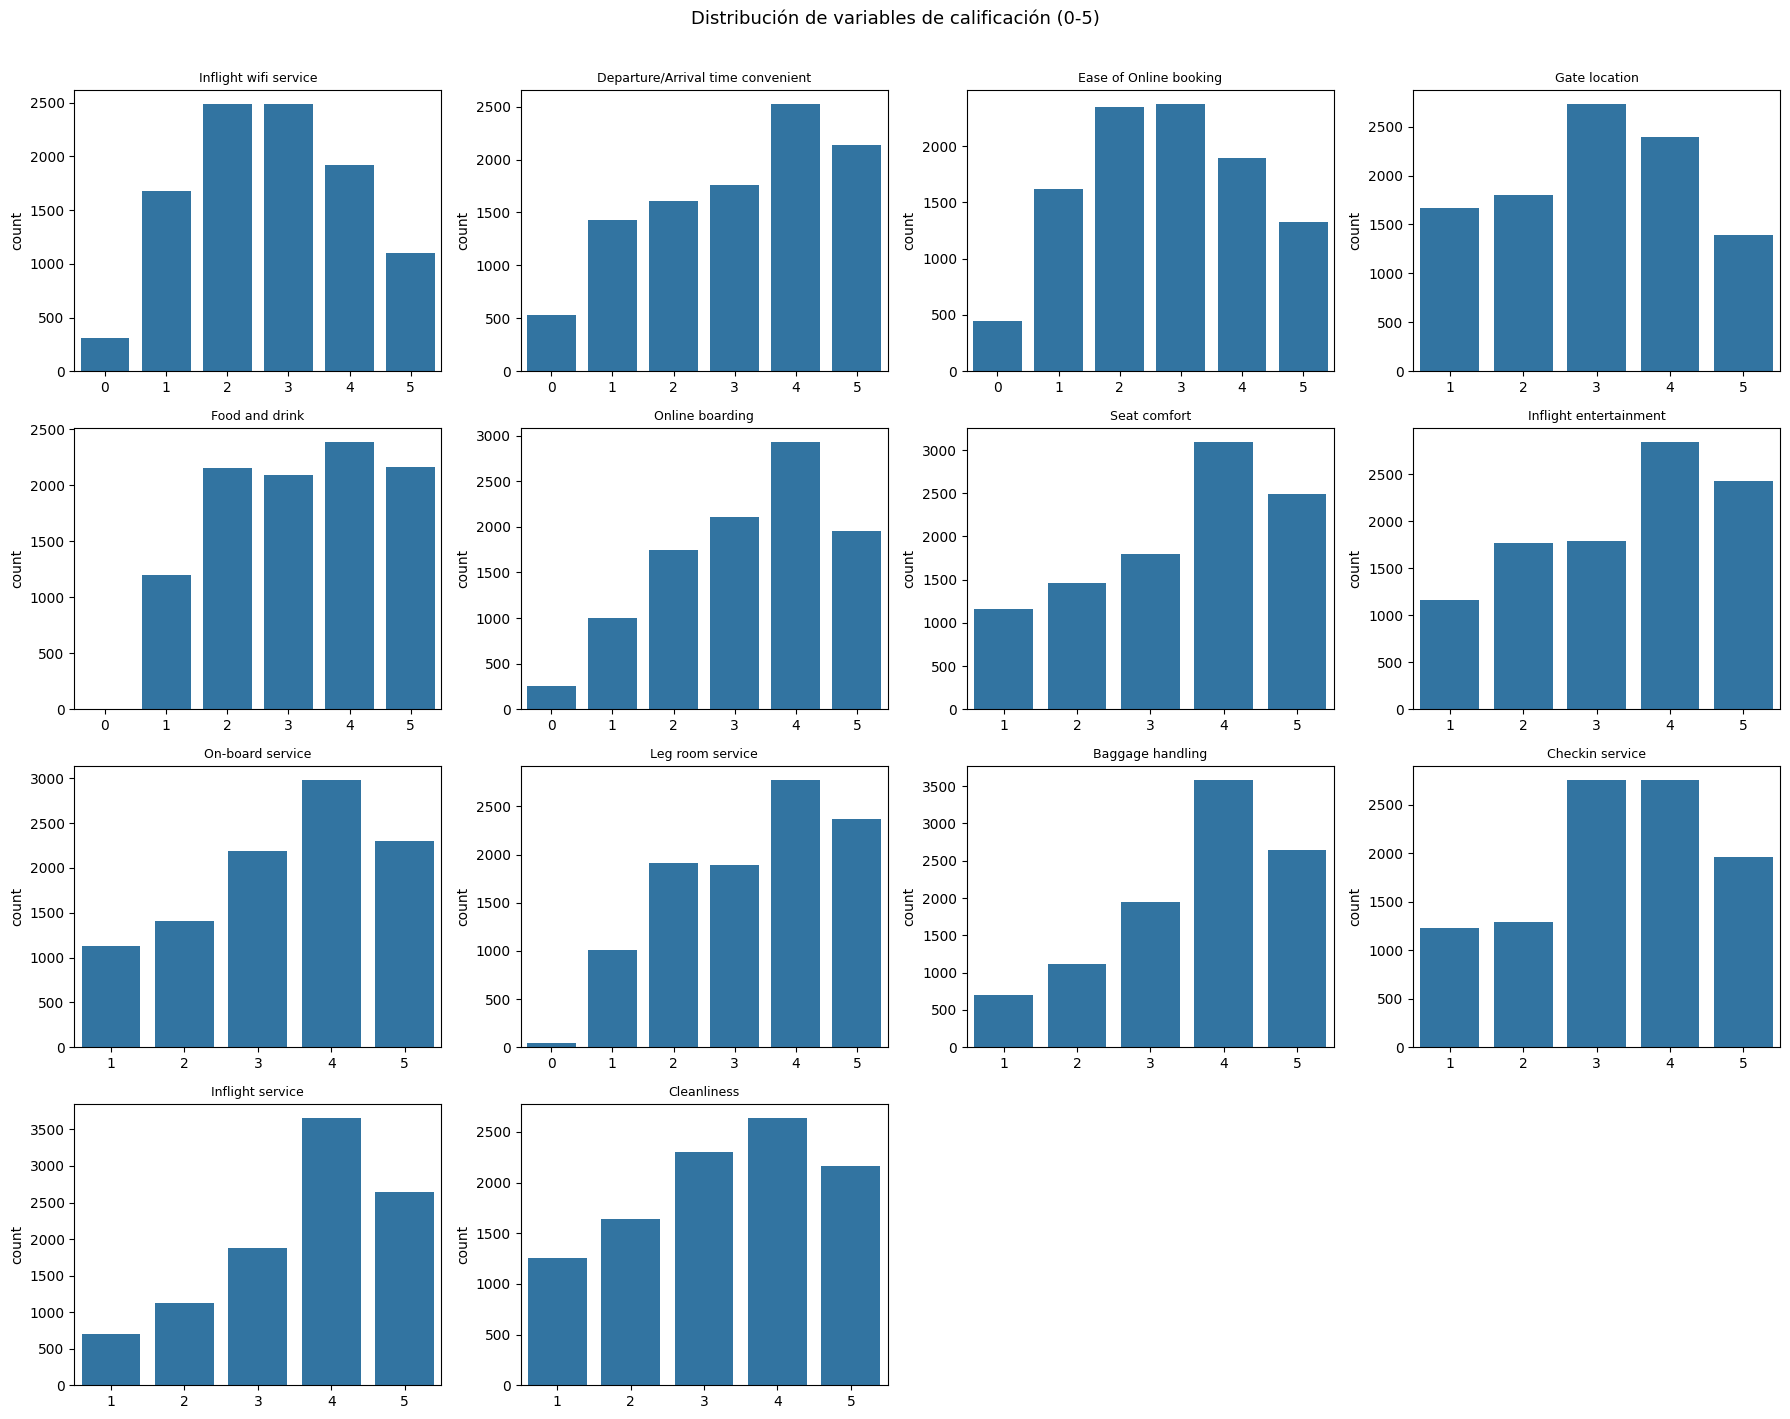

In [6]:
cols_calificaciones = [
    'Inflight wifi service', 'Departure/Arrival time convenient',
    'Ease of Online booking', 'Gate location', 'Food and drink',
    'Online boarding', 'Seat comfort', 'Inflight entertainment',
    'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Inflight service', 'Cleanliness'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cols_calificaciones):
    sns.countplot(x=df[col], ax=axes[i], order=sorted(df[col].dropna().unique()))
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

for j in range(len(cols_calificaciones), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables de calificación (0-5)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Exploración de variables categóricas

Revisamos la distribución de las variables categóricas para identificar desbalances, categorías poco frecuentes o posibles errores de calidad.

,Variable,Número de categorías únicas,Valores faltantes
0,Gender,2,0
1,Customer Type,2,0
2,Type of Travel,2,0
3,Class,3,0



Variable: Gender


,Frecuencia
Gender,
Female,5140
Male,4860


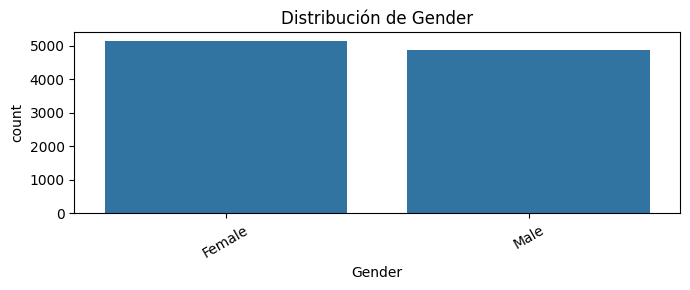


Variable: Customer Type


,Frecuencia
Customer Type,
Loyal Customer,8155
disloyal Customer,1845


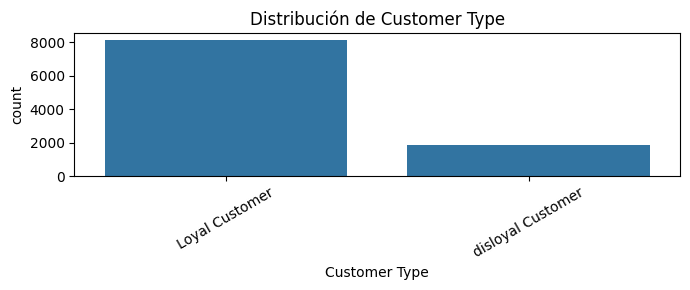


Variable: Type of Travel


,Frecuencia
Type of Travel,
Business travel,6934
Personal Travel,3066


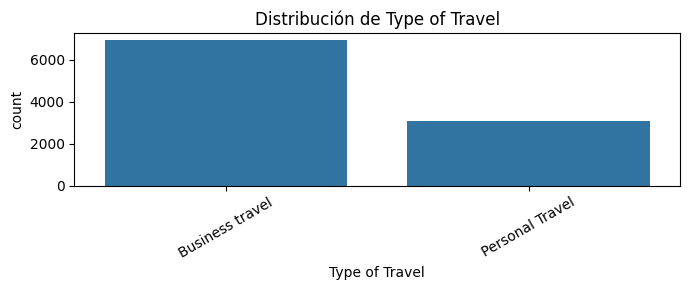


Variable: Class


,Frecuencia
Class,
Business,4856
Eco,4442
Eco Plus,702


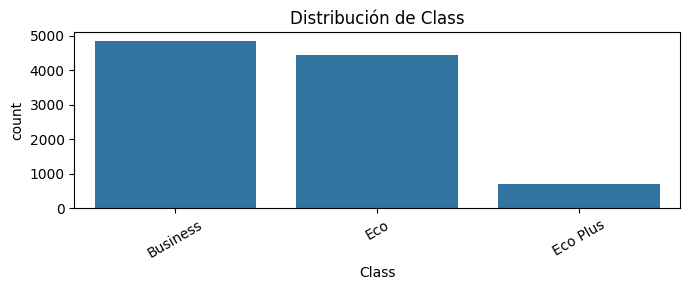

In [7]:
resumen_categoricas = pd.DataFrame({
    'Variable': variables_categoricas,
    'Número de categorías únicas': [df[col].nunique() for col in variables_categoricas],
    'Valores faltantes': [df[col].isnull().sum() for col in variables_categoricas]
})

display(resumen_categoricas)

for col in variables_categoricas:
    print(f'\nVariable: {col}')
    display(df[col].value_counts(dropna=False).to_frame('Frecuencia'))
    
    plt.figure(figsize=(7, 3))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Exploración de nulos, duplicados y outliers

In [8]:
# Nulos
valores_nulos = df.isnull().sum()
porcentaje_nulos = ((valores_nulos / len(df)) * 100).round(2)
nulos = pd.DataFrame({'Nulos': valores_nulos, 'Porcentaje (%)': porcentaje_nulos})
print("Variables con nulos:")
display(nulos[nulos['Nulos'] > 0])

# Duplicados
print(f"\nDuplicados idénticos: {df.duplicated().sum()}")

# Outliers IQR — solo variables continuas
continuas = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

for col in continuas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"\n{col}: {len(outliers)} outliers estadísticos | min={df[col].min()} max={df[col].max()}")

Variables con nulos:


,Nulos,Porcentaje (%)
Arrival Delay in Minutes,25,0.25



Duplicados idénticos: 0

Age: 0 outliers estadísticos | min=7 max=80

Flight Distance: 223 outliers estadísticos | min=31 max=4963

Departure Delay in Minutes: 1337 outliers estadísticos | min=0 max=930

Arrival Delay in Minutes: 1359 outliers estadísticos | min=0.0 max=952.0


### Matriz de correlación entre variables numéricas

Exploramos las relaciones lineales entre las variables numéricas para identificar posibles redundancias o asociaciones relevantes para el análisis de agrupación.

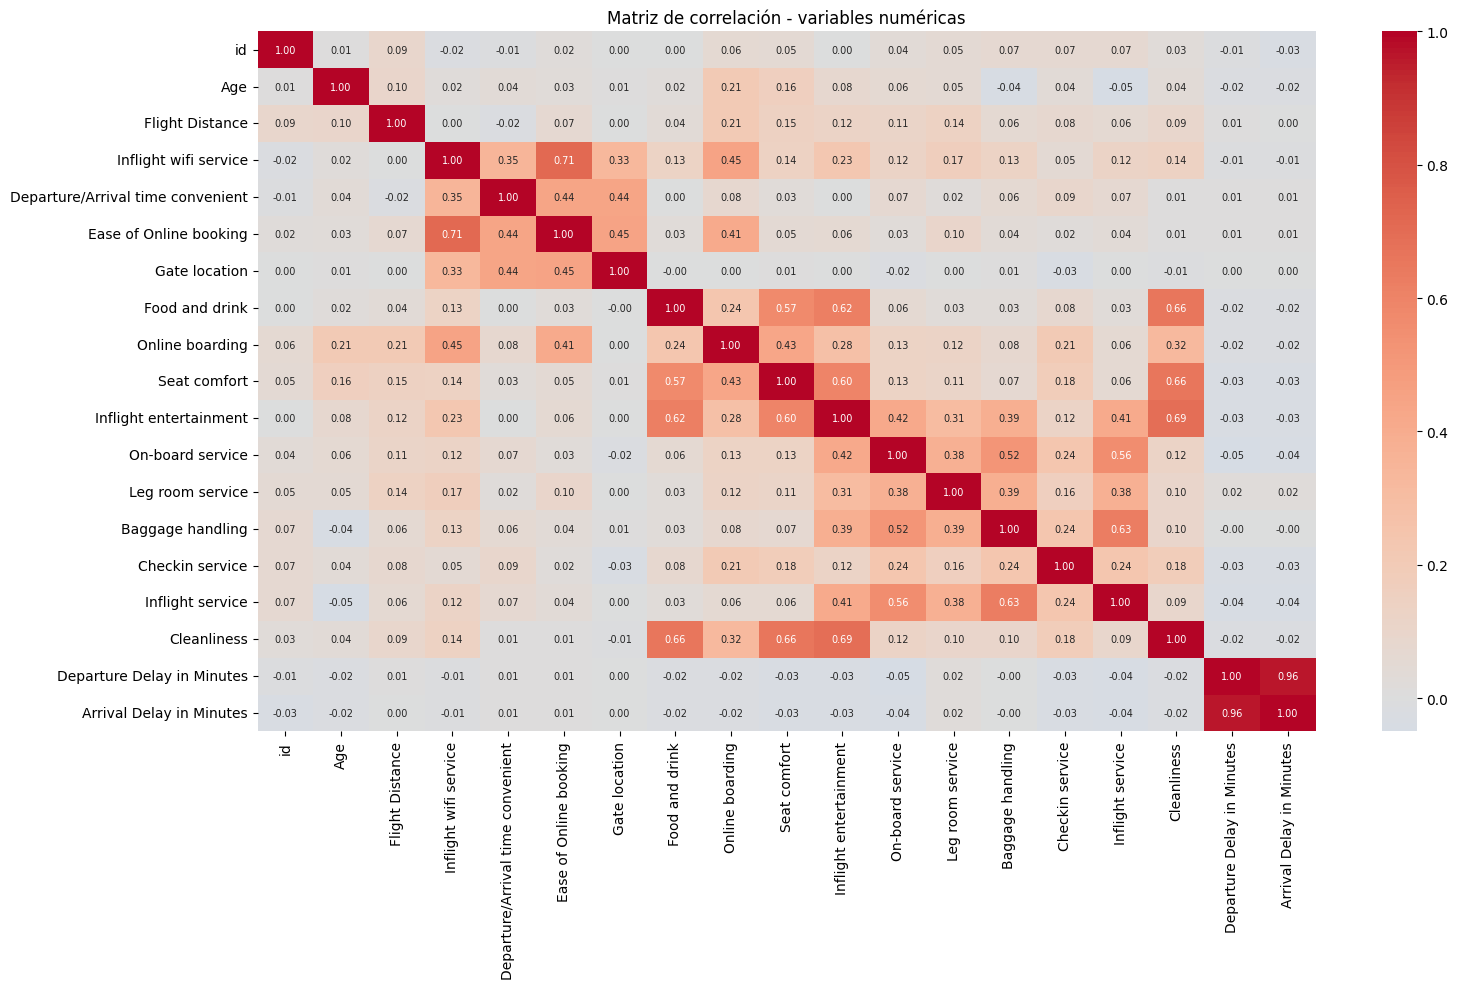

In [9]:
plt.figure(figsize=(16, 10))
sns.heatmap(df.select_dtypes(include='number').corr().round(2),
            annot=True, cmap='coolwarm', center=0, fmt='.2f', annot_kws={"size": 7})
plt.title('Matriz de correlación - variables numéricas')
plt.tight_layout()
plt.show()

### Hallazgos de la exploración de los datos

A partir de la exploración realizada, identificamos los siguientes hallazgos relevantes:

1. Todos los tipos de datos son consistentes con el diccionario. Las variables de calificación 
(escala 0–5) están almacenadas como `int64`, lo cual es correcto numéricamente, pero son 
semánticamente ordinales. La variable `id` es un identificador único que no aporta información 
para el análisis y debe excluirse del modelado.

2. La única variable con valores faltantes es `Arrival Delay in Minutes`, con 25 nulos 
(0.25% del total). Dado que la variable `Departure Delay in Minutes` tiene correlación alta 
con esta variable, se puede imputar con la mediana.

3. No se encontraron duplicados idénticos ni valores imposibles en ninguna variable. Los rangos 
observados (edad entre 7 y 80 años, distancias entre 31 y 4963 km, retrasos entre 0 y 930 
minutos) son plausibles en el contexto de una aerolínea.

4. Las variables `Departure Delay in Minutes` y `Arrival Delay in Minutes` presentan una alta 
concentración de valores cercanos a cero con una cola larga hacia la derecha (distribución 
sesgada), lo que explica la presencia de 1337 y 1359 outliers estadísticos respectivamente. 
Estos valores son posibles desde la lógica del negocio, por lo que no se eliminarán, pero 
se tendrá en cuenta al momento de escalar los datos para el modelado, pues los modelos de clustering son muy sensibles a outliers.

5. `Flight Distance` también presenta 223 outliers estadísticos con una distribución sesgada 
a la derecha, correspondiente a vuelos de larga distancia. Al igual que los retrasos, 
son valores válidos.

6. Las variables de calificación muestran distribuciones variadas: algunas como `Online boarding` 
y `Inflight service` se concentran en valores altos (3–5), mientras que `Inflight wifi service` 
y `Ease of Online booking` presentan distribuciones más uniformes, lo que sugiere mayor 
variabilidad en la percepción de estos servicios entre los pasajeros.

7. La correlación más alta entre variables numéricas se da entre `Departure Delay in Minutes` 
y `Arrival Delay in Minutes`, lo que es lógico: un retraso en salida suele propagarse a la 
llegada. Esta redundancia se considerará en la preparación de datos.

## 2. Preparación de los datos

### Propuesta de limpieza y preparación de los datos

Con base en los hallazgos de la exploración, realizaremos la preparación de los datos para 
los modelos de agrupación. La preparación tiene como objetivos:

1. Corregir los problemas de calidad identificados en la exploración.
2. Adaptar los datos a la tarea de agrupación.
3. Adaptar los datos a cada uno de los tres algoritmos que se van a utilizar.

Implementaremos la preparación de forma modular mediante funciones, con el fin de tener un proceso reutilizable para los tres modelos.

### 2.1. Librerías para la preparación y construcción de preprocesadores

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler

### 2.2. Función de limpieza base

Definimos una función que aplica las decisiones de limpieza tomadas a partir de la exploración.
Las transformaciones aplicadas son:

- Eliminación de `id`, por ser un identificador sin valor informativo para el clustering.
- Eliminación de `Arrival Delay in Minutes`, por su correlación de 0.96 con 
`Departure Delay in Minutes`, lo que la hace redundante.

In [11]:
def limpieza_base_vuelaalpes(df):
    df_clean = df.copy()

    # 1) Eliminar identificador sin valor informativo
    if 'id' in df_clean.columns:
        df_clean = df_clean.drop(columns=['id'])

    # 2) Eliminar variable redundante (correlación 0.96 con Departure Delay)
    if 'Arrival Delay in Minutes' in df_clean.columns:
        df_clean = df_clean.drop(columns=['Arrival Delay in Minutes'])

    return df_clean

### 2.3. Aplicación de la limpieza base

In [12]:
df_clean = limpieza_base_vuelaalpes(df)

print('Dimensiones antes de limpieza base:', df.shape)
print('Dimensiones después de limpieza base:', df_clean.shape)
display(df_clean.head())

Dimensiones antes de limpieza base: (10000, 23)
Dimensiones después de limpieza base: (10000, 21)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes
0,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,3,4,4,4,4,4,2,5,4,4,4,9
1,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,4,4,4,4,4,4,4,4,4,4,4,26
2,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,5,4,4,4,4,4,4,4,3,4,4,68
3,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,1,4,3,1,4,4,2,5,4,5,4,7
4,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,2,3,3,3,3,5,5,4,5,4,3,0


### 2.4. Función para construir el preprocesador

Construimos el preprocesador compartido para los tres algoritmos, distinguiendo tres grupos 
de variables según su naturaleza:

- **Variables numéricas continuas** (`Age`, `Flight Distance`, `Departure Delay in Minutes`): 
  escalado con `RobustScaler`.
- **Variables de calificación** (escala 0–5): escalado con `StandardScaler`.
- **Variables categóricas** (`Gender`, `Customer Type`, `Type of Travel`, `Class`): 
  codificación con `OneHotEncoder`.

En todos los grupos se incluye un `SimpleImputer` (imputación de nulos) como medida defensiva.

In [13]:
def construir_preprocesador(df_clean):

    num_continuas = ['Age', 'Flight Distance', 'Departure Delay in Minutes']
    num_calificaciones = [
        'Inflight wifi service', 'Departure/Arrival time convenient',
        'Ease of Online booking', 'Gate location', 'Food and drink',
        'Online boarding', 'Seat comfort', 'Inflight entertainment',
        'On-board service', 'Leg room service', 'Baggage handling',
        'Checkin service', 'Inflight service', 'Cleanliness'
    ]
    cat_cols = df_clean.select_dtypes(include=['object', 'str']).columns.tolist()
    
    # Variables continuas → RobustScaler (distribuciones sesgadas)
    num_transformer_continuas = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ])
    
    # Variables de calificación → StandardScaler 
    # (rango fijo 0-5, sin outliers extremos, escalado estándar es suficiente)
    num_transformer_calif = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ('num_continuas', num_transformer_continuas, num_continuas),
        ('num_calificaciones', num_transformer_calif, num_calificaciones),
        ('cat', cat_transformer, cat_cols)
    ])

    return preprocessor

### 2.5. Función compacta de preparación para cada modelo

Creamos una función que recibe el dataset limpio, y devuelve el 
preprocesador listo para integrarse en el pipeline de cada modelo.

In [16]:
def preparar_experimento(df_clean):
    preprocessor = construir_preprocesador(df_clean)
    print(f'Filas: {df_clean.shape[0]} | Columnas de entrada: {df_clean.shape[1]}')
    return {
        'df_clean': df_clean,
        'preprocessor': preprocessor
    }

experimento = preparar_experimento(df_clean)

Filas: 10000 | Columnas de entrada: 21


### 2.6. Justificación de las decisiones de preparación

- Se eliminó `id` por ser un identificador sin valor informativo, y `Arrival Delay in Minutes` 
por su correlación de 0.96 con `Departure Delay in Minutes`, que la hace redundante.

- Se usó `RobustScaler` para las variables continuas porque presentan distribuciones sesgadas 
con valores extremos válidos, este escalador usa la mediana y el IQR, reduciendo el efecto 
de esos outliers sin necesidad de eliminarlos. Para las calificaciones se prefirió 
`StandardScaler` dado su rango fijo (0–5) sin valores extremos. Aunque son ordinales, 
se tratan como numéricas para evitar la explosión de dimensionalidad que generaría 
`OneHotEncoder` (14 variables × 6 categorías = 84 columnas nuevas).

- El `SimpleImputer` se incluye únicamente como medida defensiva, ya que al eliminar 
`Arrival Delay in Minutes` el dataset quedó sin valores faltantes.

## 3. Modelos de Agrupación